# Part 1j: Data Augmentation with KerasCV

**Objective:** Use KerasCV's preprocessing layers for image data augmentation and compare augmented vs non-augmented training.

---

In [1]:
!pip install keras-cv -q
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_cv
print(f"KerasCV version: {keras_cv.__version__}")

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32") / 255.0, X_test.astype("float32") / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 39.4 MB/s eta 0:00:00
KerasCV version: 0.9.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


## KerasCV Augmentation Pipeline
KerasCV provides powerful preprocessing layers that work directly in the tf.data pipeline.

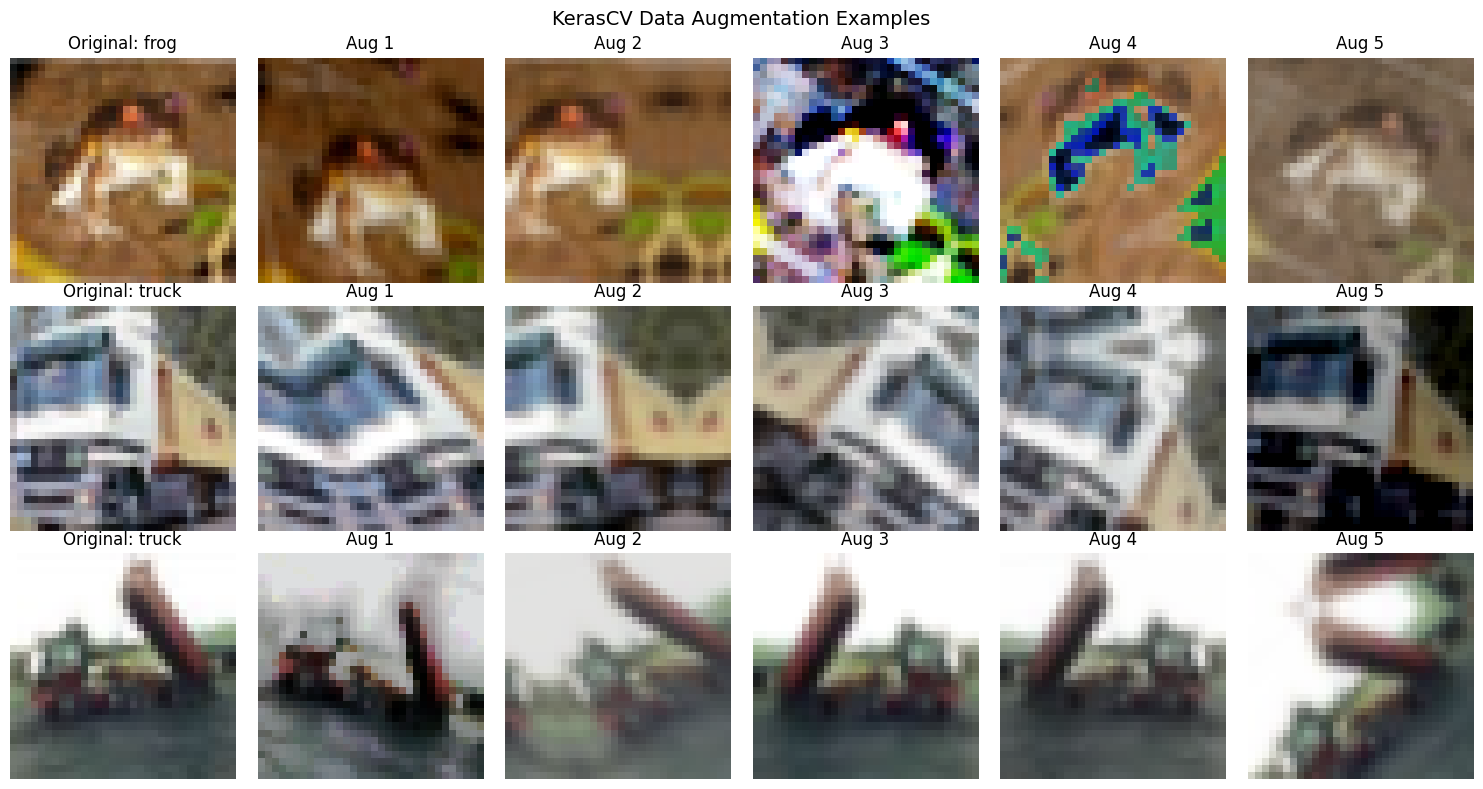

In [2]:
# Define augmentation pipeline using KerasCV layers
augmentation_pipeline = keras.Sequential([
    keras_cv.layers.RandomFlip(mode="horizontal"),
    keras_cv.layers.RandomRotation(factor=0.1),
    keras_cv.layers.RandAugment(value_range=(0.0, 1.0), augmentations_per_image=2, magnitude=0.3),
], name="augmentation")

# Visualize augmented images
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for row in range(3):
    # Original
    img = X_train[row]
    axes[row][0].imshow(img)
    axes[row][0].set_title(f"Original: {class_names[y_train[row]]}")
    axes[row][0].axis('off')
    # 5 augmented versions
    for col in range(1, 6):
        aug_img = augmentation_pipeline(tf.expand_dims(img, 0), training=True)[0]
        axes[row][col].imshow(aug_img.numpy())
        axes[row][col].set_title(f"Aug {col}")
        axes[row][col].axis('off')
plt.suptitle('KerasCV Data Augmentation Examples', fontsize=14)
plt.tight_layout(); plt.show()

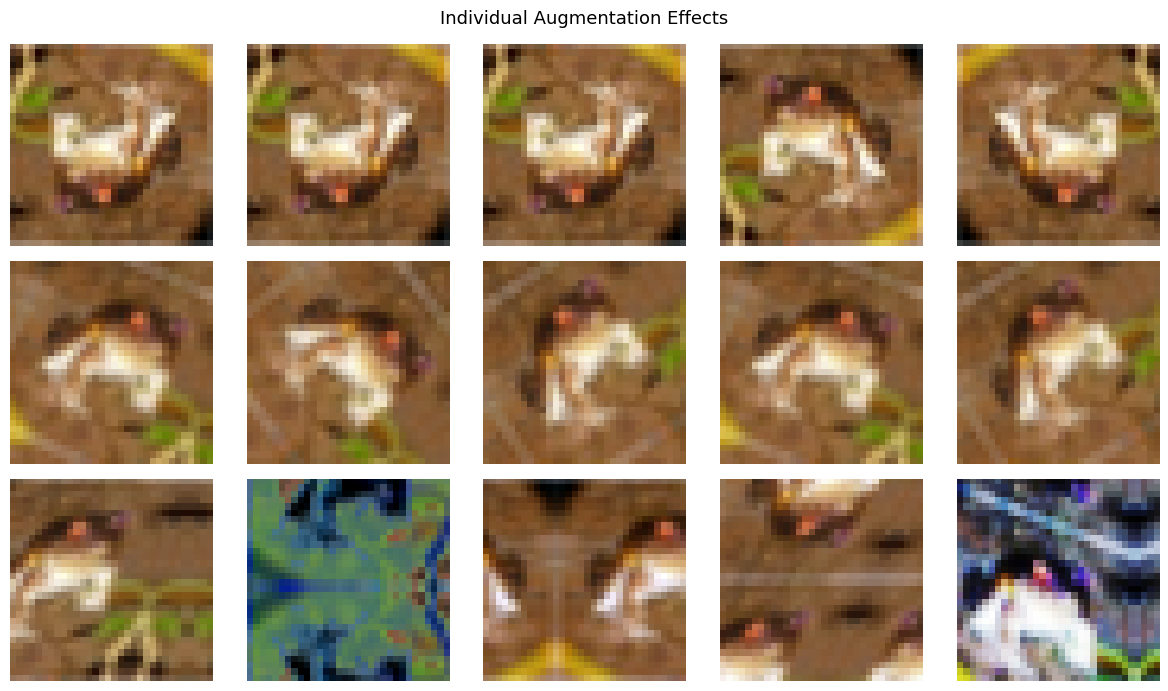

In [8]:
# Individual augmentation effects showcase
individual_augs = {
    'RandomFlip': keras_cv.layers.RandomFlip(mode="horizontal_and_vertical"),
    'RandomRotation': keras_cv.layers.RandomRotation(factor=0.2),
    'RandAugment': keras_cv.layers.RandAugment(value_range=(0.0, 1.0), augmentations_per_image=3, magnitude=0.5),
}

sample_img = X_train[0]
fig, axes = plt.subplots(len(individual_augs), 5, figsize=(12, 7))
for row, (name, aug_layer) in enumerate(individual_augs.items()):
    for col in range(5):
        aug_img = aug_layer(tf.expand_dims(sample_img, 0), training=True)[0]
        axes[row][col].imshow(aug_img.numpy().clip(0, 1))
        if col == 0: axes[row][col].set_ylabel(name, fontsize=10)
        axes[row][col].axis('off')
plt.suptitle('Individual Augmentation Effects', fontsize=13)
plt.tight_layout(); plt.show()

## A/B Test: Augmented vs Non-Augmented Training

In [6]:
# Build CNN for CIFAR-10
def build_cnn():
    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

# Baseline (no augmentation)
print("=== Training WITHOUT augmentation ===")
model_no_aug = build_cnn()
model_no_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_no_aug = model_no_aug.fit(X_train, y_train, epochs=30, batch_size=128, validation_split=0.2, verbose=1)

# With KerasCV augmentation via tf.data pipeline
print("\n=== Training WITH KerasCV augmentation ===")
# Create tf.data pipeline with augmentation
def augment_data(images, labels):
    images = augmentation_pipeline(images, training=True)
    return images, labels

train_ds = tf.data.Dataset.from_tensor_slices((X_train[:40000], y_train[:40000]))
train_ds = train_ds.batch(128).map(augment_data, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_train[40000:], y_train[40000:])).batch(128)

model_aug = build_cnn()
model_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_aug = model_aug.fit(train_ds, epochs=2, validation_data=val_ds, verbose=1)

=== Training WITHOUT augmentation ===
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.2524 - loss: 1.9537 - val_accuracy: 0.3495 - val_loss: 1.6972
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3630 - loss: 1.6784 - val_accuracy: 0.4078 - val_loss: 1.5953
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4324 - loss: 1.5319 - val_accuracy: 0.4365 - val_loss: 1.5337
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4764 - loss: 1.4278 - val_accuracy: 0.4959 - val_loss: 1.3544
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4984 - loss: 1.3673 - val_accuracy: 0.5175 - val_loss: 1.3166
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5167 - loss: 1.3143 - val_accuracy: 0.5461 - val_loss: 1.2471
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5396 - loss: 1.2657 - val_accuracy: 0.5555 - val_loss: 1.2066
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 

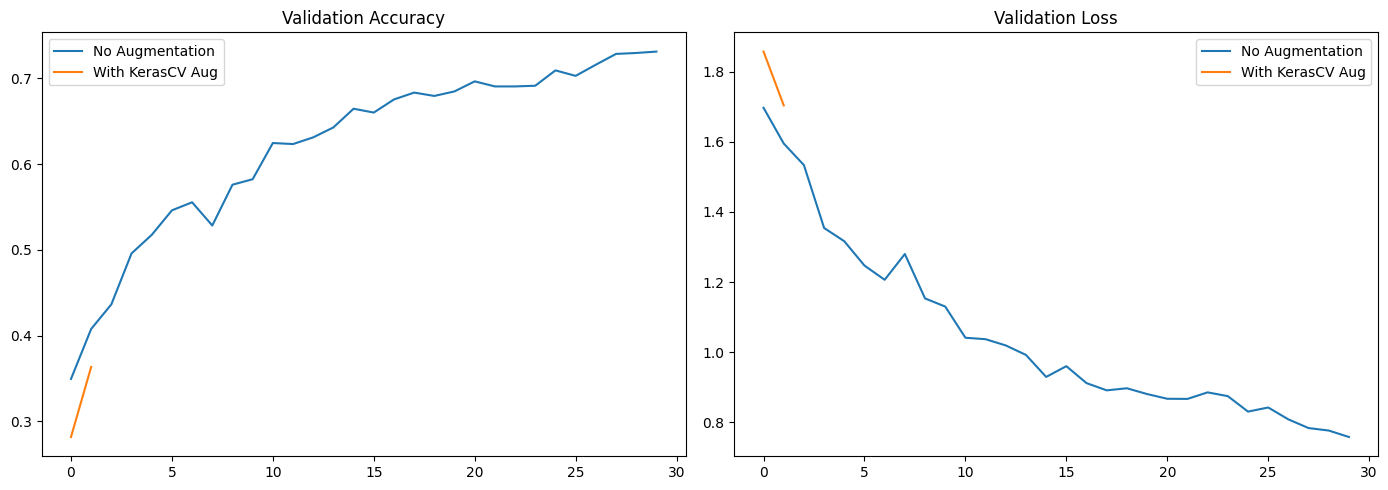

No Aug: Test Accuracy = 0.7325
With Aug: Test Accuracy = 0.3750


In [7]:
# Compare results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h_no_aug.history['val_accuracy'], label='No Augmentation')
axes[0].plot(h_aug.history['val_accuracy'], label='With KerasCV Aug')
axes[0].set_title('Validation Accuracy'); axes[0].legend()
axes[1].plot(h_no_aug.history['val_loss'], label='No Augmentation')
axes[1].plot(h_aug.history['val_loss'], label='With KerasCV Aug')
axes[1].set_title('Validation Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

# Test accuracies
for name, m in [('No Aug', model_no_aug), ('With Aug', model_aug)]:
    loss, acc = m.evaluate(X_test, y_test, verbose=0)
    print(f"{name}: Test Accuracy = {acc:.4f}")

## Key Takeaways
- KerasCV provides GPU-accelerated augmentation layers that integrate into tf.data pipelines
- **RandAugment** applies random combinations of augmentations — simple yet powerful
- Augmentation acts as implicit regularization — reduces overfitting without reducing model capacity
- Use `training=True` to apply augmentation only during training
- Particularly valuable when training data is limited